# Tune one controller gain with Bayesian optimization

Start with a noisy CartPole MAE problem, evaluate three initial controllers, and
use a Gaussian process with log expected improvement to select seven more.
This example deliberately uses one gain so we can plot the surrogate.

Install the package with its `botorch` extra before running the notebook.
Run the cells from top to bottom. See the paper for methodology and alternatives.

In [1]:
import matplotlib.pyplot as plt
import torch
from torch.quasirandom import SobolEngine
from botorch.acquisition import LogExpectedImprovement
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

import tunecontrol as tc
from tunecontrol import CartPole, CartPoleConfig, CartPoleNoise, unnormalize

dtype = torch.float64
device = torch.device("cpu")
SEED = 42
N_INITIAL = 3
N_EVALUATIONS = 10
# Default costs are around 8–9. Adjust this penalty if changing the objective.
FAILURE_PENALTY = 20.0

torch.manual_seed(SEED)
task = CartPole(CartPoleConfig(dim=1, objective="mae", noise=CartPoleNoise()))
task.setup(run_seed=SEED)
bounds = task.bounds
DIM = task.dim

## Evaluate controllers and prepare costs

Candidates use the unit interval; the task receives gains in physical coordinates.
A failed evaluation returns NaN. The simple penalty below still counts as one
observation. It is specific to this example and is not a guaranteed upper bound
on valid costs. The paper discusses better ways to handle failures.

In [2]:
def eval_objective(x: torch.Tensor, task: tc.Task) -> torch.Tensor:
    x = x.to(dtype=dtype, device=device)
    theta = unnormalize(x.reshape(-1, DIM), bounds)
    values = []
    for row in theta:
        value, _ = task.evaluate(row)
        # Simple tutorial penalty; see https://arxiv.org/abs/2609.09403
        # for better ways to handle failed controller evaluations.
        if torch.isnan(value):
            value = value.new_tensor(FAILURE_PENALTY)
        values.append(value)
    return torch.stack(values)


def standardize_costs(Y):
    mean = Y.mean()
    std = Y.std() if Y.numel() > 1 else Y.new_tensor(1.0)
    if std == 0:
        std = Y.new_tensor(1.0)
    return (Y - mean) / std, {"mean": mean, "std": std}

## Fit a model and select the next controller

Costs are standardized before fitting. A scale of one handles identical costs.
Log expected improvement is configured for minimization. All ten evaluations,
including the initial three, use the noisy task.

In [3]:
def fit_model(X, Y):
    scaled, stats = standardize_costs(Y)
    model = SingleTaskGP(X, scaled, outcome_transform=None)
    fit_gpytorch_mll(ExactMarginalLogLikelihood(model.likelihood, model))
    return model, scaled, stats

X = SobolEngine(DIM, scramble=True, seed=SEED).draw(N_INITIAL).to(dtype=dtype)
Y = eval_objective(X, task).unsqueeze(-1)
unit_bounds = torch.tensor([[0.0], [1.0]], dtype=dtype)

while len(X) < N_EVALUATIONS:
    model, scaled, _ = fit_model(X, Y)
    acquisition = LogExpectedImprovement(model, best_f=scaled.min(), maximize=False)
    candidate, _ = optimize_acqf(
        acquisition, bounds=unit_bounds, q=1, num_restarts=5, raw_samples=128,
    )
    cost = eval_objective(candidate, task).unsqueeze(-1)
    X = torch.cat((X, candidate))
    Y = torch.cat((Y, cost))
    print(f"Evaluation {len(X)}: cost={cost.item():.3f}")

Evaluation 4: cost=8.511
Evaluation 5: cost=8.455


Evaluation 6: cost=8.439
Evaluation 7: cost=8.443


Evaluation 8: cost=8.462
Evaluation 9: cost=8.431


Evaluation 10: cost=8.460


## Inspect the result

Refit using all observations. The selected controller minimizes the posterior
mean on a dense grid; the shaded region shows two posterior standard deviations.
Axes adapt to the data, including any penalty observations. This plot is an
illustration of the fitted model, not a separate performance assessment.

Selected gain: [-5.135678391959799]


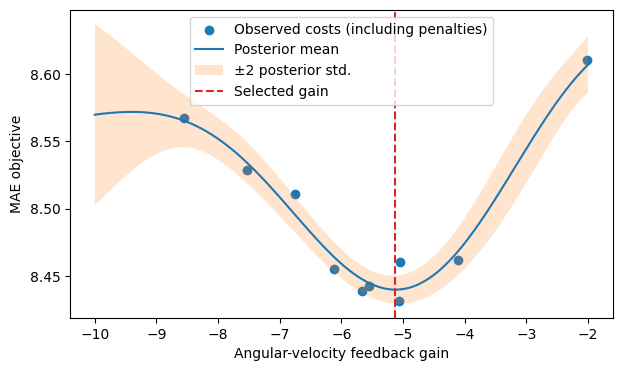

In [4]:
model, _, stats = fit_model(X, Y)
grid = torch.linspace(0, 1, 200, dtype=dtype).unsqueeze(-1)
with torch.no_grad():
    posterior = model.posterior(grid)
mean = posterior.mean.squeeze(-1) * stats["std"] + stats["mean"]
std = posterior.variance.squeeze(-1).sqrt() * stats["std"]
gains = unnormalize(grid, bounds).squeeze(-1)
selected = unnormalize(grid[mean.argmin()], bounds)
print("Selected gain:", selected.tolist())

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(unnormalize(X, bounds).squeeze(-1), Y.squeeze(-1), label="Observed costs (including penalties)")
ax.plot(gains, mean, label="Posterior mean")
ax.fill_between(gains, mean - 2 * std, mean + 2 * std, alpha=0.2, label="±2 posterior std.")
ax.axvline(selected.item(), color="tab:red", linestyle="--", label="Selected gain")
ax.set(xlabel="Angular-velocity feedback gain", ylabel="MAE objective")
ax.legend()
plt.show()